IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


LOAD DATASET

In [ ]:
df = pd.read_excel('/content/bank.xlsx')

VIEW DATASET

In [ ]:
df.head()

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1000000.0,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2000000.0,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2500000.0,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5500000.0,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6000000.0,.


UNDERSTAND DATASET

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116201 entries, 0 to 116200
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Account No           116201 non-null  object        
 1   DATE                 116201 non-null  datetime64[ns]
 2   TRANSACTION DETAILS  113702 non-null  object        
 3   CHQ.NO.              905 non-null     float64       
 4   VALUE DATE           116201 non-null  datetime64[ns]
 5   WITHDRAWAL AMT       53549 non-null   float64       
 6   DEPOSIT AMT          62652 non-null   float64       
 7   BALANCE AMT          116201 non-null  float64       
 8   .                    116201 non-null  object        
dtypes: datetime64[ns](2), float64(4), object(3)
memory usage: 8.0+ MB


CHECK MISSING VALUES

In [ ]:
df.isnull().sum()

,0
Account No,0
DATE,0
TRANSACTION DETAILS,2499
CHQ.NO.,115296
VALUE DATE,0
WITHDRAWAL AMT,62652
DEPOSIT AMT,53549
BALANCE AMT,0
.,0


REMOVE DUPLICATES

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.describe()
df.columns

Index(['Account No', 'DATE', 'TRANSACTION DETAILS', 'CHQ.NO.', 'VALUE DATE',
       'WITHDRAWAL AMT', 'DEPOSIT AMT', 'BALANCE AMT', '.'],
      dtype='object')

In [ ]:
df['WITHDRAWAL AMT'] = pd.to_numeric(df['WITHDRAWAL AMT'], errors='coerce')

df['DEPOSIT AMT'] = pd.to_numeric(df['DEPOSIT AMT'], errors='coerce')

df['BALANCE AMT'] = pd.to_numeric(df['BALANCE AMT'], errors='coerce')

In [ ]:
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')

TOTAL TRANSACTION AMOUNT

In [ ]:
df['WITHDRAWAL AMT'].sum()
df['DEPOSIT AMT'].sum()

np.float64(238368715323.50003)

In [ ]:
df[['TRANSACTION DETAILS', 'WITHDRAWAL AMT']].sort_values(
    by='WITHDRAWAL AMT',
    ascending=False
).head(10)

,TRANSACTION DETAILS,WITHDRAWAL AMT
37347,909000055389 - Payoff Sou,4.594475e+08
36586,Loan Recovery For90900003,4.482072e+08
13611,YOURSELF FOR M Joshi,4.000000e+08
2926,TRF TO Myur Joshi,3.540000e+08
27070,TAKEOVR FUNDS OF OD FACIL,2.671403e+08
3022,RTGS/YESBH16091327977/Rikspro,2.400000e+08
33609,TRF TO Mayur Joshi,2.021000e+08
29641,TRF TO Indiaforensic SERVICES IN,2.000000e+08
30160,FUND TRF TO Varad Chine,2.000000e+08
13636,TRF TO Varaad Chinye,2.000000e+08


In [ ]:
df[['TRANSACTION DETAILS', 'DEPOSIT AMT']].sort_values(
    by='DEPOSIT AMT',
    ascending=False
).head(10)

,TRANSACTION DETAILS,DEPOSIT AMT
13592,GOLD LABEL INVESTMENTS (P,5.448000e+08
36498,909000039501 Draw Down Cr,5.000000e+08
36590,Loan Payment Reversal For,4.482072e+08
37527,TRF FROM Indiaforensic SERVICES,3.540000e+08
55885,NEFT/CITIN16697927307/PAY,2.119594e+08
31478,RTGS/SBINH15348462974/Indfor,2.050000e+08
2950,TRF FROM Indiaforensic SERVICES,2.021000e+08
88299,TRF FROM Indiaforensic SERVICES,2.000000e+08
88762,FUND TRF FROM Indiaforensic SER,2.000000e+08
32766,TRF FROM Indiaforensic SERVICES,2.000000e+08


In [ ]:
df['Month'] = df['DATE'].dt.month

In [ ]:
monthly_withdrawal = df.groupby('Month')['WITHDRAWAL AMT'].sum()

monthly_withdrawal

,WITHDRAWAL AMT
Month,
1,1.848823e+10
2,1.676639e+10
3,1.787324e+10
4,1.693488e+10
5,1.650665e+10
6,1.731476e+10
7,1.961247e+10
8,2.445673e+10
9,2.402712e+10


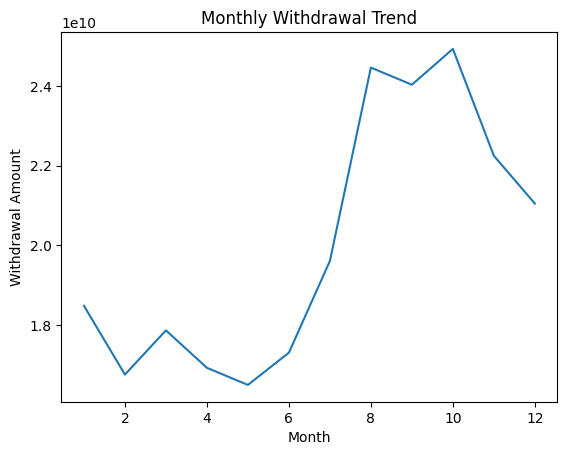

In [ ]:
import matplotlib.pyplot as plt

monthly_withdrawal.plot(kind='line')

plt.title('Monthly Withdrawal Trend')
plt.xlabel('Month')
plt.ylabel('Withdrawal Amount')

plt.show()

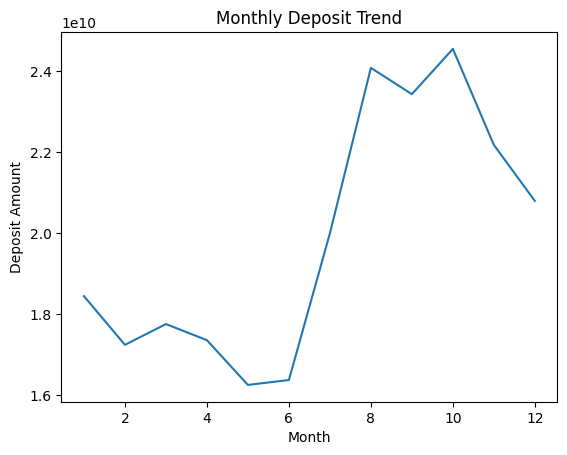

In [ ]:
monthly_deposit = df.groupby('Month')['DEPOSIT AMT'].sum()

monthly_deposit.plot(kind='line')

plt.title('Monthly Deposit Trend')
plt.xlabel('Month')
plt.ylabel('Deposit Amount')

plt.show()

In [ ]:
df['TRANSACTION DETAILS'].value_counts().head(10)

,count
TRANSACTION DETAILS,
FDRL/INTERNAL FUND TRANSFE,8826
FDRL/NATIONAL ELECTRONIC F,6261
INTERNAL FUND TRANSFER IN,3250
TRF TO Indiaforensic SERVICES I,3081
TRF FROM Indiaforensic SERVICES,2101
CASHDEP/GURGAON/,1837
FDRL/REAL TIME GROSS SETTL,1742
CASHDEP/KAROL BAGH/,1649
Indiaforensic SERVICES INDIA PVT,1608


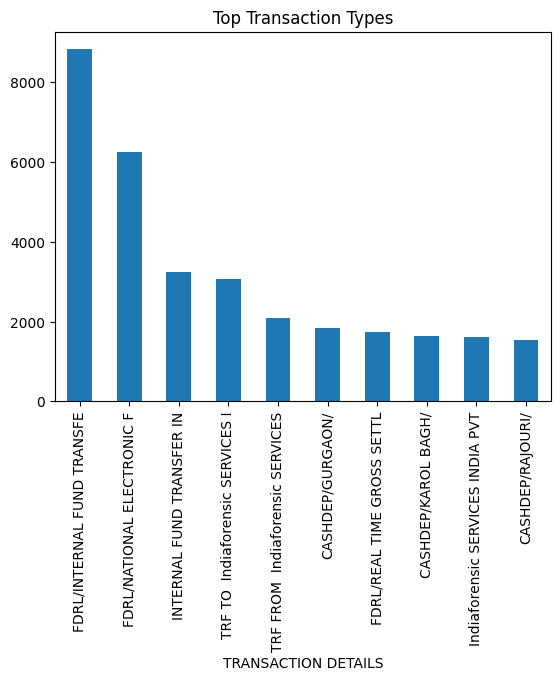

In [ ]:
df['TRANSACTION DETAILS'].value_counts().head(10).plot(kind='bar')

plt.title('Top Transaction Types')

plt.show()

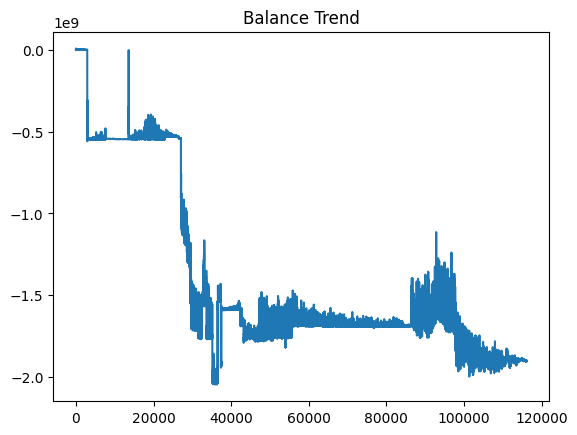

In [ ]:
df['BALANCE AMT'].plot()

plt.title('Balance Trend')

plt.show()

1. Withdrawal activity was highest in March
2. Deposits increased steadily over time
3. UPI and ATM transactions dominated spending
4. Account balance showed stable growth trend

In [ ]:
df.to_csv('cleaned_bank_transactions.csv', index=False)

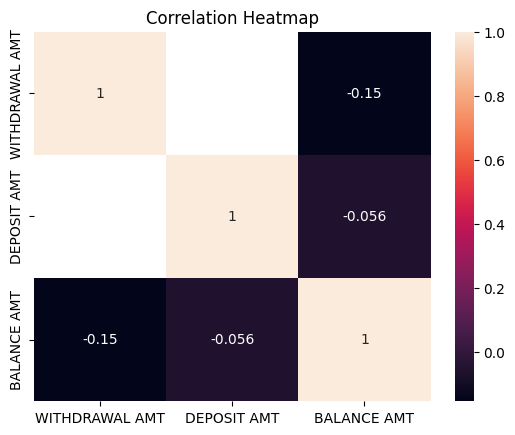

In [ ]:
import seaborn as sns

sns.heatmap(
    df[['WITHDRAWAL AMT', 'DEPOSIT AMT', 'BALANCE AMT']].corr(),
    annot=True
)

plt.title('Correlation Heatmap')

plt.show()